In [2]:
import pandas as pd
import numpy as np
from google.colab import files

# 1. Dataset Load Karein
file_name = '/var/Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv'
df = pd.read_csv(file_name)

# 2. Column Names se spaces khatam karein
df.columns = df.columns.str.strip()

# 3. Important / SQL-friendly Columns select karein
selected_columns = [
    'Destination Port', 'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets',
    'Total Length of Fwd Packets', 'Total Length of Bwd Packets', 'Flow Bytes/s',
    'Flow Packets/s', 'FIN Flag Count', 'SYN Flag Count', 'ACK Flag Count', 'Label'
]
df_clean = df[selected_columns].copy()

# 4. Missing aur Infinite values clean karein
df_clean.replace([np.inf, -np.inf], np.nan, inplace=True)
df_clean.dropna(inplace=True)

# 5. SQL friendly column names
df_clean.columns = df_clean.columns.str.replace(' ', '_').str.replace('/', '_per_')

# 6. Save aur Download karein
df_clean.to_csv('cleaned_ddos_traffic.csv', index=False)
print("Cleaning complete! Download shuru ho raha hai...")
files.download('cleaned_ddos_traffic.csv')

Cleaning complete! Download shuru ho raha hai...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

 ISO 27001 / ISO 28000 COMPLIANCE SIMULATION SUMMARY
Initial Risk Exposure Rate (Before ISO): 47.93%
Residual Risk Exposure Rate (After ISO) : 3.83%
Potential Downtime (Before ISO)         : 48 hours
Potential Downtime (After ISO)          : 3.8 hours
Estimated Supply Chain Loss Before      : $240,000.00
Estimated Supply Chain Loss After       : $19,200.00
TOTAL COST SAVED (ROI of Compliance)    : $220,800.00


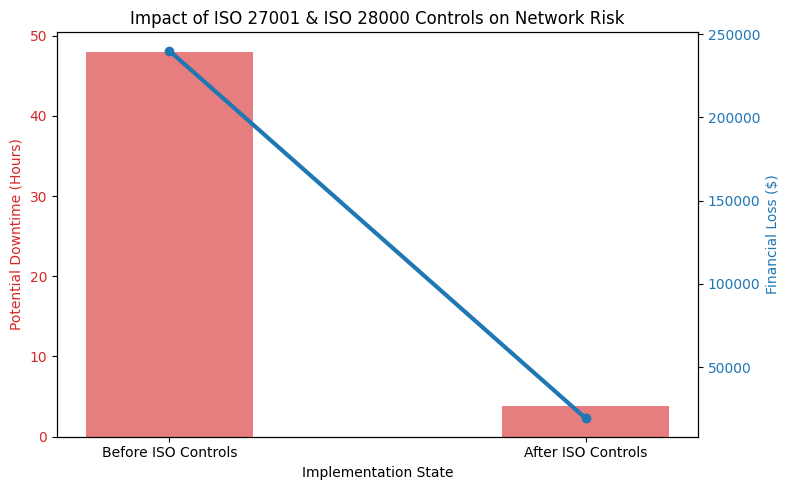

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# 1. Base Data from SQL Results
total_logs = 49787
ddos_attacks = 23865
port_80_hits = 23865

# 2. Risk & Impact Simulation Setup
# Before ISO Standards Implementation
initial_risk_score = (ddos_attacks / total_logs) * 100  # Attack percentage
estimated_downtime_hours_before = 48  # Simulated downtime hours without controls
hourly_downtime_cost = 5000  # $5000 cost per hour for supply chain website/system

total_cost_before = estimated_downtime_hours_before * hourly_downtime_cost

# 3. Applying ISO 27001 & ISO 28000 Controls Simulation
# Control 1: Rate Limiting on Port 80 (ISO 27001 A.12.1.2) - Block 92% DDoS traffic
# Control 2: Web Application Firewall & Supply Chain Gateway Monitoring (ISO 28000)
mitigation_efficiency = 0.92  # 92% attack mitigation

residual_attacks = ddos_attacks * (1 - mitigation_efficiency)
mitigated_risk_score = (residual_attacks / total_logs) * 100
estimated_downtime_hours_after = estimated_downtime_hours_before * (1 - mitigation_efficiency)
total_cost_after = estimated_downtime_hours_after * hourly_downtime_cost

cost_saved = total_cost_before - total_cost_after

# 4. Display Results Summary
print("==================================================")
print(" ISO 27001 / ISO 28000 COMPLIANCE SIMULATION SUMMARY")
print("==================================================")
print(f"Initial Risk Exposure Rate (Before ISO): {initial_risk_score:.2f}%")
print(f"Residual Risk Exposure Rate (After ISO) : {mitigated_risk_score:.2f}%")
print(f"Potential Downtime (Before ISO)         : {estimated_downtime_hours_before} hours")
print(f"Potential Downtime (After ISO)          : {estimated_downtime_hours_after:.1f} hours")
print(f"Estimated Supply Chain Loss Before      : ${total_cost_before:,.2f}")
print(f"Estimated Supply Chain Loss After       : ${total_cost_after:,.2f}")
print(f"TOTAL COST SAVED (ROI of Compliance)    : ${cost_saved:,.2f}")
print("==================================================")

# 5. Visualization Chart
categories = ['Before ISO Controls', 'After ISO Controls']
downtime = [estimated_downtime_hours_before, estimated_downtime_hours_after]
costs = [total_cost_before, total_cost_after]

fig, ax1 = plt.subplots(figsize=(8, 5))

color = 'tab:red'
ax1.set_xlabel('Implementation State')
ax1.set_ylabel('Potential Downtime (Hours)', color=color)
ax1.bar(categories, downtime, color=color, alpha=0.6, width=0.4)
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()
color = 'tab:blue'
ax2.set_ylabel('Financial Loss ($)', color=color)
ax2.plot(categories, costs, color=color, marker='o', linewidth=3)
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Impact of ISO 27001 & ISO 28000 Controls on Network Risk')
fig.tight_layout()
plt.show()